# Exoplanet Habitability Analysis Using Stellar and Planetary Characteristics
This project investigates the relationships between stellar and planetary characteristics and exoplanet habitability.The project will be using publicly available datasets from the NASA Archive and exoplanet datasets, where the analysis will identify the variables most strongly associated with the Earth Similarity Index (ESI) values. A machine learning classification model will be developed to predict whether an exoplanet is habitable based on the stellar and planetary characteristics.

## Research Question
What stellar and planetary characteristics are most strongly associated with exoplanet habitability as measured by Earth Similarity Index (ESI)?

## Project Objective
Analyze stellar and exoplanet datasets to identify characteristics most associated with habitability.

## Target Variables
- Earth Similarity Index (ESI), used to classify planets as habitable or non-habitable. 

## Planetary Features
- Planet name
- Planet Radius (Earth Radii)
- Orbital Period (days)

## Stellar Features
- Host Star
- Stellar Radius (Solar Radii)
- Stellar Temperature (K)
- Stellar Mass (Solar Masses)
- Stellar Metallicity

## Habitability Features
- Planet Type
- Planet Mass (Earth Masses)
- Stellar Flux (Earth Flux)
- Surface Temperature (K)
- Distance (Light Years)
- Planet Years (Gigayears)
- Earth Similarity Index 

## Project Approach
Following data collection and preparation this project will be used Exploratory Data Analysis to identify trends and relationships among stellar and planetary characteristics. The machine learning classification model will then be developed to predict planet habitability based on these features. The model performance will be evaluated using classification metrics, and feature importance will identify the characteristics that contribute most to habitability predictions.

## Data Acquisition
The project uses multiple publicly available stellar and exoplanet datasets from the NASA Archive and Kaggle. The datasets contain the relevant stellar and planetary features, and will be combined and prepared for exploratory data analysis, as well as the machine learning modeling.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

### Dataset 1: Planetary Systems
This dataset is acquired from the NASA Archives and contains the characteristics of the exoplanets and their host star. The dataset provides the relevant information about the exoplanets and the stars they orbit.  

In [2]:
# Load the dataset
df_stellar_planets = pd.read_csv('planetary_systems.csv', sep=",", comment="#")
# Confirm data is loaded correctly
df_stellar_planets.head()

,pl_name,hostname,default_flag,pl_refname,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,...,st_masslim,st_met,st_meterr1,st_meterr2,st_metlim,st_lum,st_lumerr1,st_lumerr2,st_lumlim,sy_refname
0,11 Com b,11 Com,1,<a refstr=TENG_ET_AL_2023 href=https://ui.adsa...,323.21,0.06,-0.05,0.0,1.178,0.00,...,0.0,-0.26,0.10,-0.10,0.0,1.97823,0.18002,-0.15868,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....
1,11 Com b,11 Com,0,<a refstr=KUNITOMO_ET_AL__2011 href=https://ui...,NaN,NaN,NaN,NaN,1.210,0.06,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....
2,11 Com b,11 Com,0,<a refstr=LIU_ET_AL__2008 href=https://ui.adsa...,326.03,0.32,-0.32,0.0,1.290,0.05,...,0.0,-0.35,0.09,-0.09,0.0,2.24300,0.07100,-0.08500,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....
3,11 UMi b,11 UMi,0,<a refstr=KUNITOMO_ET_AL__2011 href=https://ui...,NaN,NaN,NaN,NaN,1.510,0.06,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....
4,11 UMi b,11 UMi,0,<a refstr=DOLLINGER_ET_AL__2009 href=https://u...,516.22,3.25,-3.25,0.0,1.540,0.07,...,0.0,0.04,0.04,-0.04,0.0,NaN,NaN,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....


### Dataset 2: Habitable Exoplanets
This dataset contains potentially habitable exoplanets and includes some of the key characteristics and importantly contains the target variable, the Earth Similarity Index (ESI). The dataset will be used to combine with dataset one to analyze the characteristics to identify which variables are most strongly associated with habitable exoplanets.

In [3]:
# Load the dataset
df_habitable_planets = pd.read_csv('hwc_table_all.csv')
# Confirm data is loaded correctly
df_habitable_planets.head()

,Name,Type,Detection Method,Mass<br>(M<sub>E</sub>),Radius<br>(R<sub>E</sub>),Flux<br>(S<sub>E</sub>),<i>T<sub>surf</sub></i><br>(K),Period<br>(days),Distance<br>(ly),Age<br>(Gy),ESI
0,TOI-904 c,M Warm Superterran,Transit,5.340,2.167,0.524434,244.820750,83.99970,150.322365,1.5,0.658603
1,TOI-700 e,M Warm Terran,Transit,0.818,0.953,1.278049,305.688111,27.80978,101.520947,1.5,0.912032
2,TOI-700 d,M Warm Terran,Transit,1.250,1.073,0.859827,276.939259,37.42396,101.520947,1.5,0.941176
3,GJ 357 d,M Warm Superterran,Radial Velocity,6.100,2.340,0.382595,226.261383,55.66100,30.795030,NaN,0.575518
4,GJ 3293 d,M Warm Superterran,Radial Velocity,7.600,2.670,0.588593,251.304031,48.13450,65.851875,NaN,0.629777


# Data Understanding 

In [4]:
# Check the shape of the dataset
df_stellar_planets.shape

(39876, 63)

In [5]:
# Check the data types and missing values
df_stellar_planets.info()

<class 'pandas.DataFrame'>
RangeIndex: 39876 entries, 0 to 39875
Data columns (total 63 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          39876 non-null  str    
 1   hostname         39876 non-null  str    
 2   default_flag     39876 non-null  int64  
 3   pl_refname       39876 non-null  str    
 4   pl_orbper        36491 non-null  float64
 5   pl_orbpererr1    34783 non-null  float64
 6   pl_orbpererr2    34782 non-null  float64
 7   pl_orbperlim     36491 non-null  float64
 8   pl_orbsmax       22243 non-null  float64
 9   pl_orbsmaxerr1   7769 non-null   float64
 10  pl_orbsmaxerr2   7768 non-null   float64
 11  pl_orbsmaxlim    25030 non-null  float64
 12  pl_rade          27502 non-null  float64
 13  pl_radeerr1      26757 non-null  float64
 14  pl_radeerr2      26757 non-null  float64
 15  pl_radelim       30248 non-null  float64
 16  pl_radj          27502 non-null  float64
 17  pl_radjerr1      26757 

In [6]:
# Generate summary statistics
df_stellar_planets.describe()

,default_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_rade,...,st_masserr2,st_masslim,st_met,st_meterr1,st_meterr2,st_metlim,st_lum,st_lumerr1,st_lumerr2,st_lumlim
count,39876.000000,3.649100e+04,3.478300e+04,3.478200e+04,36491.000000,22243.000000,7769.000000,7768.000000,25030.000000,27502.000000,...,27825.000000,33411.000000,24978.000000,24305.000000,24305.000000,27290.000000,9788.000000,4876.000000,4821.000000,9788.000000
mean,0.157764,1.199261e+04,1.386947e+04,-3.268969e+03,-0.000247,4.760748,1.041064,-0.700819,-0.000160,5.440478,...,-0.090057,-0.000060,-0.021976,0.141447,-0.152451,-0.000183,-0.156345,0.037616,-0.041041,0.000204
std,0.364524,2.105646e+06,2.520262e+06,5.374310e+05,0.020273,179.899190,59.224583,25.530972,0.012641,71.261523,...,0.607425,0.017301,0.227004,0.097305,0.104740,0.018160,0.727305,0.039616,0.055887,0.014294
min,0.000000,9.070629e-02,0.000000e+00,-1.000000e+08,-1.000000,0.004400,0.000000,-2060.000000,-1.000000,0.270000,...,-97.100000,-1.000000,-2.500000,0.000000,-1.000000,-1.000000,-4.660000,0.000170,-1.431360,0.000000
25%,0.000000,4.366325e+00,8.060000e-06,-2.000000e-04,0.000000,0.054500,0.000750,-0.026000,0.000000,1.560000,...,-0.110000,0.000000,-0.149800,0.060000,-0.260000,0.000000,-0.467370,0.015290,-0.049890,0.000000
50%,0.000000,1.029678e+01,3.818000e-05,-3.824000e-05,0.000000,0.101100,0.002000,-0.002000,0.000000,2.302500,...,-0.067000,0.000000,-0.001400,0.120000,-0.140000,0.000000,-0.088005,0.023180,-0.022600,0.000000
75%,0.000000,2.635766e+01,2.000000e-04,-8.078725e-06,0.000000,0.221000,0.024000,-0.000770,0.000000,3.291000,...,-0.040000,0.000000,0.120000,0.220000,-0.060000,0.000000,0.303200,0.048760,-0.015420,0.000000
max,1.000000,4.020000e+08,4.700000e+08,0.000000e+00,1.000000,19000.000000,5205.000000,0.000000,0.000000,4282.980000,...,0.000000,1.000000,7.790000,0.960000,0.000000,1.000000,3.260760,0.750000,-0.000170,1.000000


In [7]:
# Count missing values in each column
df_stellar_planets.isnull().sum()

pl_name             0
hostname            0
default_flag        0
pl_refname          0
pl_orbper        3385
                ...  
st_lum          30088
st_lumerr1      35000
st_lumerr2      35055
st_lumlim       30088
sy_refname         37
Length: 63, dtype: int64

## Dataset 1 Findings
The planetary systems dataset contains 39,876 rows and 63 columns describing planetary and stellar characteristic. The dataset contains categorical and numerical features where several of the variables have missing values. The missing values will be addressed during data cleaning. The summary statistics show a wide range of values across planetary and stellar variables, suggesting a large variation among the exoplanet systems.

In [8]:
# Check the shape of the dataset
df_habitable_planets.shape

(70, 11)

In [9]:
# Check the data types and missing values
df_habitable_planets.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Name                            70 non-null     str    
 1   Type                            70 non-null     str    
 2   Detection Method                70 non-null     str    
 3   Mass<br>(M<sub>E</sub>)         70 non-null     float64
 4   Radius<br>(R<sub>E</sub>)       70 non-null     float64
 5   Flux<br>(S<sub>E</sub>)         70 non-null     float64
 6   <i>T<sub>surf</sub></i><br>(K)  70 non-null     float64
 7   Period<br>(days)                70 non-null     float64
 8   Distance<br>(ly)                70 non-null     float64
 9   Age<br>(Gy)                     49 non-null     float64
 10  ESI                             70 non-null     float64
dtypes: float64(8), str(3)
memory usage: 6.1 KB


In [10]:
# Generate summary statistics
df_habitable_planets.describe()

,Mass<br>(M<sub>E</sub>),Radius<br>(R<sub>E</sub>),Flux<br>(S<sub>E</sub>),<i>T<sub>surf</sub></i><br>(K),Period<br>(days),Distance<br>(ly),Age<br>(Gy),ESI
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,49.000000,70.000000
mean,5.288748,1.770514,0.866255,269.496160,73.921945,511.267378,3.891020,0.738725
std,6.247585,0.557559,0.392595,34.614972,80.613442,852.655136,2.358261,0.109235
min,0.388000,0.788000,0.252321,198.928456,4.049219,4.243909,0.400000,0.475466
25%,2.202500,1.302500,0.534217,245.259471,18.499800,29.848419,2.000000,0.658704
50%,4.060000,1.780000,0.851427,275.595301,36.769980,101.520947,4.000000,0.729044
75%,5.680000,2.198500,1.211178,298.738599,110.803975,816.172774,6.000000,0.827250
max,36.000000,3.030000,1.636043,325.367512,384.843000,4975.575011,8.000000,0.968362


In [11]:
# Count missing values in each column
df_habitable_planets.isnull().sum()

Name                               0
Type                               0
Detection Method                   0
Mass<br>(M<sub>E</sub>)            0
Radius<br>(R<sub>E</sub>)          0
Flux<br>(S<sub>E</sub>)            0
<i>T<sub>surf</sub></i><br>(K)     0
Period<br>(days)                   0
Distance<br>(ly)                   0
Age<br>(Gy)                       21
ESI                                0
dtype: int64

## Dataset 2 Findings
The habitable exoplanets dataset contains 70 rows and 11 columns related to the habitable exoplanets. All variables are complete except for the *Age* variable, which contains 21 missing values. The dataset contains the target variable, the Earth Similarity Index (ESI), and provides habitability measurements that will be merged with the planetary systems dataset for further analysis.

# Data Preparation / Data Cleaning

In [12]:
# Create dataset copies for cleaning
stellar_planets_clean = df_stellar_planets.copy()
habitable_planets_clean = df_habitable_planets.copy()

## Dataset 1 Cleaning

In [13]:
# Select relevant features for analysis
stellar_planets_clean = stellar_planets_clean[
    [
        'pl_name', 
        'hostname', 
        'pl_orbper', 
        'pl_orbsmax', 
        'pl_rade',
        'pl_bmasse', 
        'pl_orbeccen', 
        'pl_insol', 
        'pl_eqt', 
        'st_spectype', 
        'st_teff', 
        'st_rad', 
        'st_mass', 
        'st_met', 
        'st_lum'
   ]
]

# Verify selected features
stellar_planets_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 39876 entries, 0 to 39875
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_name      39876 non-null  str    
 1   hostname     39876 non-null  str    
 2   pl_orbper    36491 non-null  float64
 3   pl_orbsmax   22243 non-null  float64
 4   pl_rade      27502 non-null  float64
 5   pl_bmasse    7403 non-null   float64
 6   pl_orbeccen  18949 non-null  float64
 7   pl_insol     17331 non-null  float64
 8   pl_eqt       17501 non-null  float64
 9   st_spectype  3055 non-null   str    
 10  st_teff      36257 non-null  float64
 11  st_rad       36467 non-null  float64
 12  st_mass      33404 non-null  float64
 13  st_met       24978 non-null  float64
 14  st_lum       9788 non-null   float64
dtypes: float64(12), str(3)
memory usage: 4.6 MB


In [14]:
# Check for duplicates
stellar_planets_clean.duplicated().sum()

np.int64(5483)

In [15]:
# Remove duplicates
stellar_planets_clean = stellar_planets_clean.drop_duplicates()

# Verify duplicates are removed
stellar_planets_clean.duplicated().sum()

np.int64(0)

In [16]:
# Evaluate Percentage of Missing Values
missing_values = stellar_planets_clean.isnull().sum()
missing_percentage = (missing_values / len(stellar_planets_clean)) * 100
missing_percentage

pl_name         0.000000
hostname        0.000000
pl_orbper       9.554270
pl_orbsmax     51.184834
pl_rade        35.649696
pl_bmasse      78.728230
pl_orbeccen    60.518129
pl_insol       65.219667
pl_eqt         64.734103
st_spectype    91.134824
st_teff        10.228826
st_rad          9.612421
st_mass        18.762539
st_met         42.997122
st_lum         71.561073
dtype: float64

In [17]:
# Drop columns with more than 50% missing values
stellar_planets_clean = stellar_planets_clean.dropna(thresh=len(stellar_planets_clean) * 0.5, axis=1)

# Verify columns are dropped
stellar_planets_clean.info()

<class 'pandas.DataFrame'>
Index: 34393 entries, 0 to 39875
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pl_name    34393 non-null  str    
 1   hostname   34393 non-null  str    
 2   pl_orbper  31107 non-null  float64
 3   pl_rade    22132 non-null  float64
 4   st_teff    30875 non-null  float64
 5   st_rad     31087 non-null  float64
 6   st_mass    27940 non-null  float64
 7   st_met     19605 non-null  float64
dtypes: float64(6), str(2)
memory usage: 2.4 MB


In [18]:
# Fill missing values with median for numerical columns
numerical_cols = stellar_planets_clean.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    stellar_planets_clean[col] = stellar_planets_clean[col].fillna(stellar_planets_clean[col].median())

# Verify missing values are filled
stellar_planets_clean.isnull().sum()

pl_name      0
hostname     0
pl_orbper    0
pl_rade      0
st_teff      0
st_rad       0
st_mass      0
st_met       0
dtype: int64

In [19]:
# Rename columns for clarity
stellar_planets_clean = stellar_planets_clean.rename(columns={
    'pl_name': 'planet_name',
    'hostname': 'host_star',
    'pl_orbper': 'orbital_period_days',
    'pl_rade': 'planet_radius_earth',
    'st_teff': 'star_temperature_K',
    'st_rad': 'stellar_radius_solar',
    'st_mass': 'stellar_mass_solar_masses',
    'st_met': 'stellar_metallicity'
})

# Verify column names are updated
stellar_planets_clean.info()

<class 'pandas.DataFrame'>
Index: 34393 entries, 0 to 39875
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   planet_name                34393 non-null  str    
 1   host_star                  34393 non-null  str    
 2   orbital_period_days        34393 non-null  float64
 3   planet_radius_earth        34393 non-null  float64
 4   star_temperature_K         34393 non-null  float64
 5   stellar_radius_solar       34393 non-null  float64
 6   stellar_mass_solar_masses  34393 non-null  float64
 7   stellar_metallicity        34393 non-null  float64
dtypes: float64(6), str(2)
memory usage: 2.4 MB


### Dataset 1 Cleaning Summary
The planetary system dataset was cleaned to improve quality and ensure consistency for analysis. First, only the most relevant characteristics were selected for analysis, reducing the dataset to specific stellar and planet characteristics. Duplicated entries were identified, and 5,483 duplicates were removed from the dataset. The reduction in the duplicates improves reliability of analysis. Missing values were identified next. Features with more than 50% missing values were removed because the significant proportion of missing values will negatively impact model performance and reduce reliability of the model and analysis. Next, to preserve as much data as possible, missing numerical values were filled using the median of each respective feature. Median imputation was used because it is less sensitive to outliers than mean imputation, and helps preserve the distribution of the data. Finally, after cleaning the dataset 8 features and 34,393 observations remain, each of the remaining features were renamed to improve clarity. The names are understandable and include metrics for the specified measurement of the feature. The dataset is now ready for analysis and machine learning modeling. 

## Dataset 2 Cleaning

In [20]:
# Select relevant features for analysis
habitable_planets_clean = habitable_planets_clean[
    [
        'Name',
        'Type',
        'Mass<br>(M<sub>E</sub>)',
        'Radius<br>(R<sub>E</sub>)',
        'Flux<br>(S<sub>E</sub>)',
        '<i>T<sub>surf</sub></i><br>(K)',
        'Period<br>(days)',
        'Distance<br>(ly)',
        'Age<br>(Gy)',
        'ESI'
    ]
]

In [21]:
# Check for duplicates
habitable_planets_clean.duplicated().sum()

np.int64(0)

In [22]:
# Evaluate Percentage of missing values, only Age has missing values from data understanding above
missing_percentage = (habitable_planets_clean.isnull().sum() / len(habitable_planets_clean)) * 100
missing_percentage

Name                               0.0
Type                               0.0
Mass<br>(M<sub>E</sub>)            0.0
Radius<br>(R<sub>E</sub>)          0.0
Flux<br>(S<sub>E</sub>)            0.0
<i>T<sub>surf</sub></i><br>(K)     0.0
Period<br>(days)                   0.0
Distance<br>(ly)                   0.0
Age<br>(Gy)                       30.0
ESI                                0.0
dtype: float64

In [23]:
# Fill missing values in Age column with median
habitable_planets_clean['Age<br>(Gy)'] = habitable_planets_clean['Age<br>(Gy)'].fillna(habitable_planets_clean['Age<br>(Gy)'].median())

# Verify missing values are filled
habitable_planets_clean.isnull().sum()

Name                              0
Type                              0
Mass<br>(M<sub>E</sub>)           0
Radius<br>(R<sub>E</sub>)         0
Flux<br>(S<sub>E</sub>)           0
<i>T<sub>surf</sub></i><br>(K)    0
Period<br>(days)                  0
Distance<br>(ly)                  0
Age<br>(Gy)                       0
ESI                               0
dtype: int64

In [24]:
# Rename columns for clarity
habitable_planets_clean = habitable_planets_clean.rename(columns={
    'Name': 'planet_name',
    'Type': 'planet_type',
    'Mass<br>(M<sub>E</sub>)': 'planet_mass_earth',
    'Radius<br>(R<sub>E</sub>)': 'planet_radius_earth',
    'Flux<br>(S<sub>E</sub>)': 'stellar_flux_earth',
    '<i>T<sub>surf</sub></i><br>(K)': 'surface_temperature_K',
    'Period<br>(days)': 'orbital_period_days',
    'Distance<br>(ly)': 'distance_light_years',
    'Age<br>(Gy)': 'planet_age_gigayears',
    'ESI': 'earth_similarity_index'
})

# Verify column names are updated
habitable_planets_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   planet_name             70 non-null     str    
 1   planet_type             70 non-null     str    
 2   planet_mass_earth       70 non-null     float64
 3   planet_radius_earth     70 non-null     float64
 4   stellar_flux_earth      70 non-null     float64
 5   surface_temperature_K   70 non-null     float64
 6   orbital_period_days     70 non-null     float64
 7   distance_light_years    70 non-null     float64
 8   planet_age_gigayears    70 non-null     float64
 9   earth_similarity_index  70 non-null     float64
dtypes: float64(8), str(2)
memory usage: 5.6 KB


### Dataset 2 Cleaning Summary
The habitable exoplanets dataset was cleaned to improve quality and prepare it for analysis. First, the most relevant planetary features were selected with the target variable, the Earth Similarity Index (ESI). The dataset was checked for duplicates and none were identified. Next, only the planet age contained missing values, where approximately 30% of the observations were missing. Tp preserve the data, the missing age values were filled using the median age of the feature. Similarly, median imputation was selected because it is less sensitive to outliers tha mean imputation and helps preserve the overall distribution of the data. Lastly, the column names were renamed to improve clarity and readable. The feature names that matched dataset names, were named correspondingly, so the datasets are merged accurately. The cleaned dataset contains 10 features and 70 observations, and is now ready for analysis and machine learning modeling.   

# Merge the Cleaned Datasets

In [25]:
# Merge the two datasets on planet_name
merged_planets = pd.merge(stellar_planets_clean, habitable_planets_clean, on='planet_name', how='inner')

# Verify merged dataset
merged_planets.info()

<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   planet_name                324 non-null    str    
 1   host_star                  324 non-null    str    
 2   orbital_period_days_x      324 non-null    float64
 3   planet_radius_earth_x      324 non-null    float64
 4   star_temperature_K         324 non-null    float64
 5   stellar_radius_solar       324 non-null    float64
 6   stellar_mass_solar_masses  324 non-null    float64
 7   stellar_metallicity        324 non-null    float64
 8   planet_type                324 non-null    str    
 9   planet_mass_earth          324 non-null    float64
 10  planet_radius_earth_y      324 non-null    float64
 11  stellar_flux_earth         324 non-null    float64
 12  surface_temperature_K      324 non-null    float64
 13  orbital_period_days_y      324 non-null    float64
 14  dista

In [26]:
# Check planet names in merged dataset
merged_planets['planet_name'].nunique()

70

In [27]:
# Count how many radius values are the same
(merged_planets['planet_radius_earth_x'] == merged_planets['planet_radius_earth_y']).sum()

np.int64(43)

In [28]:
# Statistically compare the two radius columns
merged_planets[['planet_radius_earth_x', 'planet_radius_earth_y']].describe()

,planet_radius_earth_x,planet_radius_earth_y
count,324.000000,324.000000
mean,2.198386,1.754235
std,2.703893,0.462463
min,0.530000,0.788000
25%,1.597500,1.410000
50%,2.208500,1.780000
75%,2.370000,2.170000
max,38.670000,3.030000


In [29]:
# Statistically compare the two orbital period columns
merged_planets[['orbital_period_days_x', 'orbital_period_days_y']].describe()

,orbital_period_days_x,orbital_period_days_y
count,324.000000,324.000000
mean,92.106996,101.525451
std,88.305510,89.631206
min,4.049219,4.049219
25%,24.737080,32.939623
50%,56.056065,63.336270
75%,129.945770,140.252400
max,384.847556,384.843000


In [30]:
# Check missing values in the merged dataset
merged_planets.isnull().sum()

planet_name                  0
host_star                    0
orbital_period_days_x        0
planet_radius_earth_x        0
star_temperature_K           0
stellar_radius_solar         0
stellar_mass_solar_masses    0
stellar_metallicity          0
planet_type                  0
planet_mass_earth            0
planet_radius_earth_y        0
stellar_flux_earth           0
surface_temperature_K        0
orbital_period_days_y        0
distance_light_years         0
planet_age_gigayears         0
earth_similarity_index       0
dtype: int64

In [31]:
# Drop duplicate columns from the merged dataset
merged_planets = merged_planets.drop(columns=['orbital_period_days_x', 'planet_radius_earth_x'])

# Rename remaining columns for clarity
merged_planets = merged_planets.rename(columns={'orbital_period_days_y': 'orbital_period_days', 
                                                'planet_radius_earth_y': 'planet_radius_earth'})
# Verify final merged dataset
merged_planets.info()

<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   planet_name                324 non-null    str    
 1   host_star                  324 non-null    str    
 2   star_temperature_K         324 non-null    float64
 3   stellar_radius_solar       324 non-null    float64
 4   stellar_mass_solar_masses  324 non-null    float64
 5   stellar_metallicity        324 non-null    float64
 6   planet_type                324 non-null    str    
 7   planet_mass_earth          324 non-null    float64
 8   planet_radius_earth        324 non-null    float64
 9   stellar_flux_earth         324 non-null    float64
 10  surface_temperature_K      324 non-null    float64
 11  orbital_period_days        324 non-null    float64
 12  distance_light_years       324 non-null    float64
 13  planet_age_gigayears       324 non-null    float64
 14  earth

### Merge Summary
The planetary systems and habitable planet datasets were merged on *planet_name*, resulting in 324 observations and 15 features. There were duplicated columns created during the merge, *orbital_period_days* and *planet_radius_earth* were examined then removed. The related columns for the habitable planet dataset were kept because they are directly associated with the Earth Similarity Index (ESI) and related to the habitable measurements for the analysis. The merged dataset does not contain missing values, and is now ready for further analysis.

# Exploratory Data Analysis (EDA)

In [32]:
## Statistical Examination
merged_planets.describe()

,star_temperature_K,stellar_radius_solar,stellar_mass_solar_masses,stellar_metallicity,planet_mass_earth,planet_radius_earth,stellar_flux_earth,surface_temperature_K,orbital_period_days,distance_light_years,planet_age_gigayears,earth_similarity_index
count,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000
mean,4278.906667,0.613515,0.623762,-0.077474,6.319910,1.754235,0.914823,273.654971,101.525451,872.037611,4.036667,0.746048
std,919.529162,0.314817,0.286900,0.171220,8.265157,0.462463,0.386191,32.611130,89.631206,967.388712,1.928145,0.088520
min,2520.000000,0.107000,0.080200,-0.760000,0.388000,0.788000,0.252321,198.928456,4.049219,4.243909,0.400000,0.475466
25%,3525.000000,0.421000,0.429000,-0.182500,2.540000,1.410000,0.587250,251.843755,32.939623,124.026037,2.900000,0.678714
50%,4141.000000,0.600000,0.636818,0.017000,4.120000,1.780000,0.894316,278.800421,63.336270,716.894150,4.000000,0.730737
75%,4931.750000,0.781000,0.896250,0.017000,5.650000,2.170000,1.264154,297.996788,140.252400,1092.916140,4.900000,0.814264
max,5906.000000,3.204000,1.592000,0.300000,36.000000,3.030000,1.636043,325.367512,384.843000,4975.575011,8.000000,0.968362


## Univariate Analysis

### Earth Similarity Index (ESI)

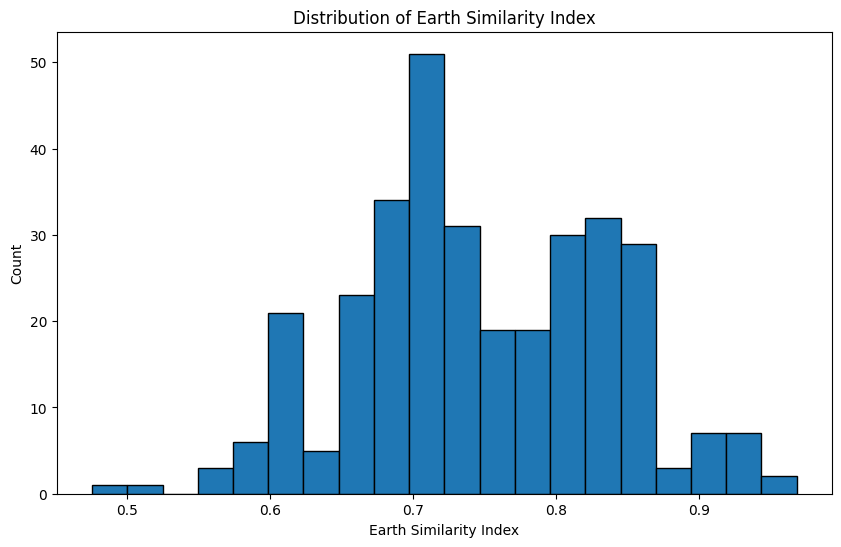

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(merged_planets['earth_similarity_index'], bins=20, edgecolor='black')
plt.xlabel('Earth Similarity Index')
plt.ylabel('Count')
plt.title('Distribution of Earth Similarity Index')
plt.show()

The Earth Similarity Index (ESI) distribution is concentrated approximately in the range of 0.65 and 0.85, while peaking between 0.70 and 0.75. The histogram suggests that most planets for the dataset exhibit moderate to high similarity or Earth. Few planets show low values of ESI, while slightly more show higher values of ESI, which suggests a relatively consistent range of habitability characteristics.

### Planet Radius

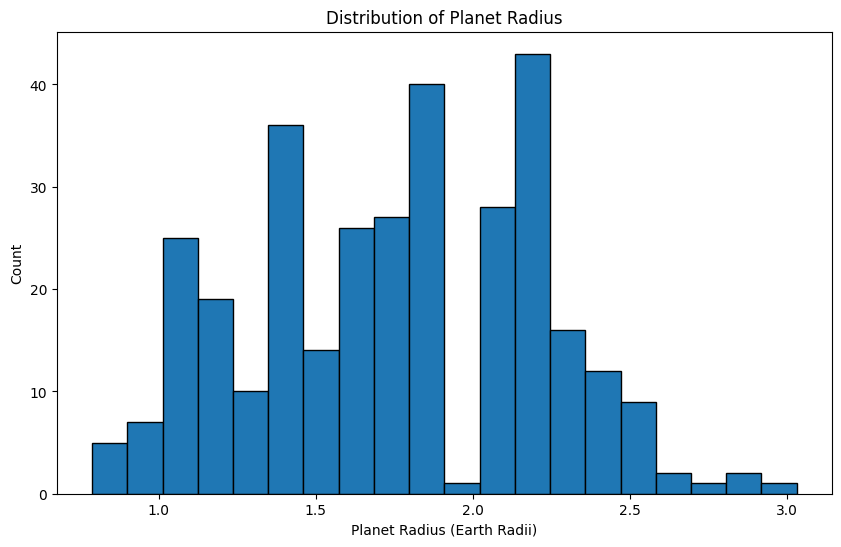

In [35]:
plt.figure(figsize=(10, 6))
plt.hist(merged_planets['planet_radius_earth'], bins=20, edgecolor='black')
plt.xlabel('Planet Radius (Earth Radii)')
plt.ylabel('Count')
plt.title('Distribution of Planet Radius')
plt.show()

The distribution of planet radius shows the range of planet sizes, where most planets cluster close to the size or less than double of the Earth, 1.0 -2.0. A smaller number of planets have larger radii, greater than twice the size of the Earth. The overall distribution suggests most common habitable planets are Earth-sized and super-Earth sized.